### ParticleNet
In this example, we will train a graph neural network, called "ParticleNet".
And compare the performance between giving $\Delta R$ as input for ```edge_attribute``` or not.

In [2]:
import os; WORKDIR = f"{os.getcwd()}/.."
import sys; sys.path.append(f"{WORKDIR}/libPython")
import ROOT

import torch
import torch.nn.functional as F
from torch.nn import BatchNorm1d, Sequential, ReLU, Linear, Dropout
from torch_geometric.nn import GraphNorm
from torch_geometric.nn import MessagePassing, TransformerConv
from torch_geometric.nn import global_mean_pool, knn_graph
from torch_geometric.utils import dropout_edge
from torch_geometric.loader import DataLoader
from torch.utils.tensorboard import SummaryWriter
from sklearn.utils import shuffle
from DataManager import rtfileToDataList, GraphDataset

import matplotlib.pyplot as plt
import networkx as nx

In [3]:
maxSize = -1
SIGNAL = "MHc-130_MA-90"
BACKGROUND = "ttZ"
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"@@@@ Using DEVICE {DEVICE}")

@@@@ Using DEVICE cuda


In [4]:
class EdgeConv(MessagePassing):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__(aggr="mean")
        self.mlp = Sequential(
                Linear(2*in_channels, hidden_channels), ReLU(), BatchNorm1d(hidden_channels), Dropout(0.4),
                Linear(out_channels, hidden_channels), ReLU(), BatchNorm1d(hidden_channels), Dropout(0.4),
                Linear(out_channels, hidden_channels), ReLU(), BatchNorm1d(hidden_channels), Dropout(0.4)
                )

    def forward(self, x, edge_index, batch=None):
        return self.propagate(edge_index, x=x, batch=batch)

    def message(self, x_i, x_j):
        tmp = torch.cat([x_i, x_j - x_i], dim=1)
        return self.mlp(tmp)


class DynamicEdgeConv(EdgeConv):
    def __init__(self, in_channels, hidden_channels, out_channels, dropout_p, training, k=4):
        super().__init__(in_channels, hidden_channels, out_channels)
        self.shortcut = Sequential(Linear(in_channels, out_channels), ReLU())
        self.training = training
        self.dropout_p = dropout_p
        self.k = k

    def forward(self, x, edge_index=None, batch=None):
        if edge_index is None: edge_index = knn_graph(x, self.k, batch, loop=False, flow=self.flow)
        edge_index, _ = dropout_edge(edge_index, p=self.dropout_p, training=self.training)
        out = super().forward(x, edge_index, batch=batch)
        out += self.shortcut(x)
        return out


class ParticleNet(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, edge_dim=None, dropout_p=0.2):
        super(ParticleNet, self).__init__()
        self.gn0 = GraphNorm(in_channels)
        self.bn0 = BatchNorm1d(hidden_channels)
        self.conv1 = TransformerConv(in_channels, hidden_channels, dropout_p=dropout_p, edge_dim=edge_dim, training=self.training)
        self.conv2 = DynamicEdgeConv(hidden_channels, hidden_channels, hidden_channels, dropout_p=dropout_p, training=self.training, k=4)
        self.conv3 = DynamicEdgeConv(hidden_channels, hidden_channels, hidden_channels, dropout_p=dropout_p, training=self.training, k=4)
        self.dense1 = Linear(hidden_channels, hidden_channels)
        self.dense2 = Linear(hidden_channels, hidden_channels)
        self.output = Linear(hidden_channels, out_channels)
        self.dropout_p = dropout_p
    
    def forward(self, x, edge_index, edge_attribute=None, batch=None, return_attention_weights=False):
        # convolution layers
        x = self.gn0(x, batch=batch)
        conv1, attention_weights = self.conv1(x, edge_index, edge_attr=edge_attribute, return_attention_weights=True)
        conv1 = F.elu(conv1)
        conv2 = self.conv2(conv1, edge_index, batch=batch)
        conv3 = self.conv3(conv2, edge_index, batch=batch)
        x = conv1+conv2+conv3
        
        # readout layers
        x = global_mean_pool(x, batch=batch)
        
        # dense layers
        x = self.bn0(x)
        x = F.alpha_dropout(x, p=0.4)
        x = F.selu(self.dense1(x))
        x = F.alpha_dropout(x, p=0.4)
        x = F.selu(self.dense2(x))
        x = self.output(x)

        if return_attention_weights:
            return F.log_softmax(x, dim=1), attention_weights
        else:
            return F.log_softmax(x, dim=1)

In [5]:
# train model with deltaR as edge attributes
rtSig = ROOT.TFile.Open(f"{WORKDIR}/DATA/{SIGNAL}.root")
rtBkg = ROOT.TFile.Open(f"{WORKDIR}/DATA/{BACKGROUND}.root")

sigDataList = shuffle(rtfileToDataList(rtSig, isSignal=True, edgeAttributeList=["deltaR"], maxSize=maxSize), random_state=42); rtSig.Close()
bkgDataList = shuffle(rtfileToDataList(rtBkg, isSignal=False, edgeAttributeList=["deltaR"], maxSize=maxSize), random_state=42); rtBkg.Close()
dataList = shuffle(sigDataList+bkgDataList, random_state=42)

trainset = GraphDataset(dataList[:int(len(dataList)*0.6)])
validset = GraphDataset(dataList[int(len(dataList)*0.6):int(len(dataList)*0.7)])
testset  = GraphDataset(dataList[int(len(dataList)*0.7):])

trainLoader = DataLoader(trainset, batch_size=512, pin_memory=True, shuffle=True)
validLoader = DataLoader(validset, batch_size=512, pin_memory=True, shuffle=False)
testLoader = DataLoader(testset, batch_size=512, pin_memory=True, shuffle=False)

@@@@ no. of dataList ends with 105000
@@@@ no. of dataList ends with 105000


In [6]:
def train(model, optimizer, scheduler):
    model.train()
    
    train_loss = 0.
    for data in trainLoader:
        data = data.to(DEVICE)
        out = model(data.x, data.edge_index, data.edge_attribute, batch=data.batch)
        optimizer.zero_grad()
        loss = F.cross_entropy(out, data.y)
        loss.backward()
        optimizer.step()
        train_loss += loss.sum().item()
    scheduler.step()
    return train_loss / len(trainLoader.dataset)

def test(model, loader):
    model.eval()
    loss = 0.
    correct = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(DEVICE)
            out = model(data.x, data.edge_index, data.edge_attribute, batch=data.batch)
            pred = out.argmax(dim=1)
            loss += F.cross_entropy(out, data.y).sum().item()
            correct += pred.eq(data.y).sum().item()
    loss /= len(loader.dataset)
    correct /= len(loader.dataset)
    return (loss, correct)

In [7]:
model = ParticleNet(in_channels=8, hidden_channels=64, out_channels=2, edge_dim=1).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.0002, max_lr=0.005,
                                                         step_size_up=3, step_size_down=5,
                                                         cycle_momentum=False)
writer = SummaryWriter("./runs/ex4")
print(model)

for epoch in range(30):
    loss = train(model, optimizer, scheduler)
    trainLoss, trainAcc = test(model, trainLoader)
    validLoss, validAcc = test(model, validLoader)
    writer.add_scalar("Loss/train", trainLoss, epoch)
    writer.add_scalar("Loss/valid", validLoss, epoch)
    writer.add_scalar("Acc/train", trainAcc, epoch)
    writer.add_scalar("Acc/valid", validAcc, epoch)
    
    print(f"[EPOCH {epoch}]\tTrain Acc: {trainAcc*100:.2f}\tTrain Loss: {trainLoss:.4e}")
    print(f"[EPOCH {epoch}]\tValid Acc: {validAcc*100:.2f}\tValid Loss: {validLoss:.4e}\n")
    
writer.flush()
writer.close()

ParticleNet(
  (gn0): GraphNorm(8)
  (bn0): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1): TransformerConv(8, 64, heads=1)
  (conv2): DynamicEdgeConv()
  (conv3): DynamicEdgeConv()
  (dense1): Linear(in_features=64, out_features=64, bias=True)
  (dense2): Linear(in_features=64, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=2, bias=True)
)
[EPOCH 0]	Train Acc: 63.61	Train Loss: 1.2540e-03
[EPOCH 0]	Valid Acc: 63.07	Valid Loss: 1.2930e-03

[EPOCH 1]	Train Acc: 74.59	Train Loss: 1.0176e-03
[EPOCH 1]	Valid Acc: 74.38	Valid Loss: 1.0636e-03

[EPOCH 2]	Train Acc: 74.87	Train Loss: 1.0059e-03
[EPOCH 2]	Valid Acc: 75.08	Valid Loss: 1.0369e-03

[EPOCH 3]	Train Acc: 75.49	Train Loss: 9.8049e-04
[EPOCH 3]	Valid Acc: 75.53	Valid Loss: 1.0144e-03

[EPOCH 4]	Train Acc: 76.33	Train Loss: 9.6191e-04
[EPOCH 4]	Valid Acc: 76.33	Valid Loss: 9.9250e-04

[EPOCH 5]	Train Acc: 77.22	Train Loss: 9.3960e-04
[EPOCH 5]	Valid Acc: 77.05	Val

In [8]:
rtSig = ROOT.TFile.Open(f"{WORKDIR}/DATA/{SIGNAL}.root")
rtBkg = ROOT.TFile.Open(f"{WORKDIR}/DATA/{BACKGROUND}.root")

sigDataList = shuffle(rtfileToDataList(rtSig, isSignal=True, edgeAttributeList=["deltaR"], returnParticleTypes=True, maxSize=100), random_state=42); rtSig.Close()
bkgDataList = shuffle(rtfileToDataList(rtBkg, isSignal=False, edgeAttributeList=["deltaR"], returnParticleTypes=True, maxSize=100), random_state=42); rtBkg.Close()
dataList = shuffle(sigDataList+bkgDataList, random_state=42)

trainset = GraphDataset(dataList[:int(len(dataList)*0.6)])
validset = GraphDataset(dataList[int(len(dataList)*0.6):int(len(dataList)*0.7)])
testset  = GraphDataset(dataList[int(len(dataList)*0.7):])

@@@@ no. of dataList ends with 100
@@@@ no. of dataList ends with 100


In [11]:
data = sigDataList[5]
model.to("cpu")
model.eval()
with torch.no_grad():
    out, weights = model(data.x, data.edge_index, data.edge_attribute, return_attention_weights=True)

# edge_mask dict: {(u, v): weights}
edge_mask_dict = {}
for (u, v, weight) in zip(weights[0][0].numpy(), weights[0][1].numpy(), weights[1].numpy()):
    if (u == v): continue
    if u > v: u, v = v, u
    edge_mask_dict[(u, v)] = weight.mean()
print(edge_mask_dict)

{(0, 1): 0.23263487, (0, 2): 0.36043102, (0, 3): 0.01537452, (0, 4): 0.30946684, (0, 5): 0.0124057345, (0, 6): 0.047087684, (0, 7): 0.02259934, (1, 2): 0.07248412, (1, 3): 0.18748955, (1, 4): 0.10364502, (1, 5): 0.11349779, (1, 6): 0.15428214, (1, 7): 0.06486662, (2, 3): 0.070422165, (2, 4): 0.0800141, (2, 5): 0.04486045, (2, 6): 0.044259164, (2, 7): 0.0436023, (3, 4): 0.013323773, (3, 5): 0.061313294, (3, 6): 0.0028655557, (3, 7): 0.023219515, (4, 5): 0.10265079, (4, 6): 0.104505286, (4, 7): 0.12487764, (5, 6): 0.03609669, (5, 7): 0.10347366, (6, 7): 0.16170838}


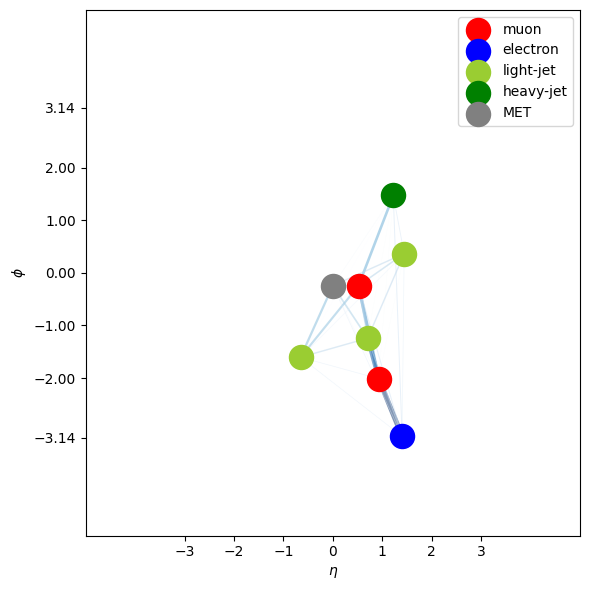

In [12]:
G = nx.Graph()
positions = {}
muons = []
electrons = []
jets = []
bjets = []
METv = []
for i, features in enumerate(data.x):
    thisParticle = ROOT.TLorentzVector()
    thisParticle.SetPxPyPzE(features[1], features[2], features[3], features[0])
    positions[i] = (thisParticle.Eta(), thisParticle.Phi())
for i, particleType in enumerate(data.particleTypes):
    if particleType == "muon": muons.append(i)
    if particleType == "electron": electrons.append(i)
    if particleType == "light-jet": jets.append(i)
    if particleType == "heavy-jet": bjets.append(i)
    if particleType == "METv": METv.append(i)
G.add_nodes_from(positions.keys())
G.add_edges_from(edge_mask_dict.keys())
edge_color = [edge_mask_dict[(u, v)] for u, v, in G.edges()]
widths = [x*10 for x in edge_color]

plt.figure(figsize=(6, 6))
nx.draw_networkx_nodes(G, positions, nodelist=muons, node_color="red", label="muon")
nx.draw_networkx_nodes(G, positions, nodelist=electrons, node_color="blue", label="electron")
nx.draw_networkx_nodes(G, positions, nodelist=jets, node_color="yellowgreen", label="light-jet")
nx.draw_networkx_nodes(G, positions, nodelist=bjets, node_color="green", label="heavy-jet")
nx.draw_networkx_nodes(G, positions, nodelist=METv, node_color="gray", label="MET")
nx.draw_networkx_edges(G, positions, edgelist=edge_mask_dict.keys(), edge_color=edge_color, alpha=0.5, width=widths, edge_cmap=plt.cm.Blues)
plt.legend(loc="upper right")
plt.xlabel(r"$\eta$")
plt.ylabel(r"$\phi$")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.xticks([-3., -2., -1., 0., 1., 2., 3])
plt.yticks([-3.14, -2., -1., 0., 1., 2., 3.14])
plt.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
plt.tight_layout()
plt.show()

In [13]:
# train without "invariant mass" implemented
rtSig = ROOT.TFile.Open(f"{WORKDIR}/DATA/{SIGNAL}.root")
rtBkg = ROOT.TFile.Open(f"{WORKDIR}/DATA/{BACKGROUND}.root")

sigDataList = shuffle(rtfileToDataList(rtSig, isSignal=True,  maxSize=maxSize), random_state=42); rtSig.Close()
bkgDataList = shuffle(rtfileToDataList(rtBkg, isSignal=False, maxSize=maxSize), random_state=42); rtBkg.Close()
dataList = shuffle(sigDataList+bkgDataList, random_state=42)

trainset = GraphDataset(dataList[:int(len(dataList)*0.6)])
validset = GraphDataset(dataList[int(len(dataList)*0.6):int(len(dataList)*0.7)])
testset  = GraphDataset(dataList[int(len(dataList)*0.7):])

trainLoader = DataLoader(trainset, batch_size=512, pin_memory=True, shuffle=True)
validLoader = DataLoader(validset, batch_size=512, pin_memory=True, shuffle=False)
testLoader = DataLoader(testset, batch_size=512, pin_memory=True, shuffle=False)

@@@@ no. of dataList ends with 105000
@@@@ no. of dataList ends with 105000


In [14]:
def train(model, optimizer, scheduler):
    model.train()
    
    train_loss = 0.
    for data in trainLoader:
        data = data.to(DEVICE)
        out = model(data.x, data.edge_index, batch=data.batch)
        optimizer.zero_grad()
        loss = F.cross_entropy(out, data.y)
        loss.backward()
        optimizer.step()
        train_loss += loss.sum().item()
    scheduler.step()
    return train_loss / len(trainLoader.dataset)

def test(model, loader):
    model.eval()
    loss = 0.
    correct = 0
    with torch.no_grad():
        for data in loader:
            data = data.to(DEVICE)
            out = model(data.x, data.edge_index, batch=data.batch)
            pred = out.argmax(dim=1)
            loss += F.cross_entropy(out, data.y).sum().item()
            correct += pred.eq(data.y).sum().item()
    loss /= len(loader.dataset)
    correct /= len(loader.dataset)
    return (loss, correct)

In [15]:
model = ParticleNet(in_channels=8, hidden_channels=64, out_channels=2).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.002)
scheduler = torch.optim.lr_scheduler.CyclicLR(optimizer, base_lr=0.0002, max_lr=0.005,
                                                         step_size_up=3, step_size_down=5,
                                                         cycle_momentum=False)
writer = SummaryWriter("./runs/ex4")
print(model)

for epoch in range(30):
    loss = train(model, optimizer, scheduler)
    trainLoss, trainAcc = test(model, trainLoader)
    validLoss, validAcc = test(model, validLoader)
    writer.add_scalar("Loss/train", trainLoss, epoch)
    writer.add_scalar("Loss/valid", validLoss, epoch)
    writer.add_scalar("Acc/train", trainAcc, epoch)
    writer.add_scalar("Acc/valid", validAcc, epoch)
    
    print(f"[EPOCH {epoch}]\tTrain Acc: {trainAcc*100:.2f}\tTrain Loss: {trainLoss:.4e}")
    print(f"[EPOCH {epoch}]\tValid Acc: {validAcc*100:.2f}\tValid Loss: {validLoss:.4e}\n")
    
writer.flush()
writer.close()

ParticleNet(
  (gn0): GraphNorm(8)
  (bn0): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1): TransformerConv(8, 64, heads=1)
  (conv2): DynamicEdgeConv()
  (conv3): DynamicEdgeConv()
  (dense1): Linear(in_features=64, out_features=64, bias=True)
  (dense2): Linear(in_features=64, out_features=64, bias=True)
  (output): Linear(in_features=64, out_features=2, bias=True)
)


[EPOCH 0]	Train Acc: 57.20	Train Loss: 1.3340e-03
[EPOCH 0]	Valid Acc: 56.28	Valid Loss: 1.3715e-03

[EPOCH 1]	Train Acc: 71.66	Train Loss: 1.0907e-03
[EPOCH 1]	Valid Acc: 71.19	Valid Loss: 1.1336e-03

[EPOCH 2]	Train Acc: 72.83	Train Loss: 1.0656e-03
[EPOCH 2]	Valid Acc: 72.30	Valid Loss: 1.1164e-03

[EPOCH 3]	Train Acc: 72.72	Train Loss: 1.0667e-03
[EPOCH 3]	Valid Acc: 71.95	Valid Loss: 1.1099e-03

[EPOCH 4]	Train Acc: 73.97	Train Loss: 1.0235e-03
[EPOCH 4]	Valid Acc: 73.95	Valid Loss: 1.0623e-03

[EPOCH 5]	Train Acc: 75.13	Train Loss: 9.9081e-04
[EPOCH 5]	Valid Acc: 74.61	Valid Loss: 1.0395e-03

[EPOCH 6]	Train Acc: 75.29	Train Loss: 9.8413e-04
[EPOCH 6]	Valid Acc: 74.64	Valid Loss: 1.0369e-03

[EPOCH 7]	Train Acc: 76.14	Train Loss: 9.6436e-04
[EPOCH 7]	Valid Acc: 75.43	Valid Loss: 1.0085e-03

[EPOCH 8]	Train Acc: 76.88	Train Loss: 9.4101e-04
[EPOCH 8]	Valid Acc: 76.16	Valid Loss: 9.9126e-04

[EPOCH 9]	Train Acc: 76.68	Train Loss: 9.4572e-04
[EPOCH 9]	Valid Acc: 75.89	Valid Loss: 9.

In [19]:
rtSig = ROOT.TFile.Open(f"{WORKDIR}/DATA/{SIGNAL}.root")
rtBkg = ROOT.TFile.Open(f"{WORKDIR}/DATA/{BACKGROUND}.root")

sigDataList = shuffle(rtfileToDataList(rtSig, isSignal=True, returnParticleTypes=True, maxSize=100), random_state=42); rtSig.Close()
bkgDataList = shuffle(rtfileToDataList(rtBkg, isSignal=False, returnParticleTypes=True, maxSize=100), random_state=42); rtBkg.Close()
dataList = shuffle(sigDataList+bkgDataList, random_state=42)

trainset = GraphDataset(dataList[:int(len(dataList)*0.6)])
validset = GraphDataset(dataList[int(len(dataList)*0.6):int(len(dataList)*0.7)])
testset  = GraphDataset(dataList[int(len(dataList)*0.7):])

@@@@ no. of dataList ends with 100
@@@@ no. of dataList ends with 100


In [22]:
data = sigDataList[5]
model.to("cpu")
model.eval()
with torch.no_grad():
    out, weights = model(data.x, data.edge_index, return_attention_weights=True)

# edge_mask dict: {(u, v): weights}
edge_mask_dict = {}
for (u, v, weight) in zip(weights[0][0].numpy(), weights[0][1].numpy(), weights[1].numpy()):
    if (u == v): continue
    if u > v: u, v = v, u
    edge_mask_dict[(u, v)] = weight.mean()
print(edge_mask_dict)

{(0, 1): 0.7901791, (0, 2): 0.029777324, (0, 3): 0.029303823, (0, 4): 0.02317414, (0, 5): 0.03518343, (0, 6): 0.036230367, (0, 7): 0.056151804, (1, 2): 0.031894885, (1, 3): 0.036850397, (1, 4): 0.015157843, (1, 5): 0.01588009, (1, 6): 0.030233601, (1, 7): 0.019197093, (2, 3): 0.088583596, (2, 4): 0.11554205, (2, 5): 0.14809123, (2, 6): 0.1806936, (2, 7): 0.15851875, (3, 4): 0.08375859, (3, 5): 0.022926284, (3, 6): 0.08547752, (3, 7): 0.047374327, (4, 5): 0.11332452, (4, 6): 0.14128596, (4, 7): 0.14396815, (5, 6): 0.18531479, (5, 7): 0.13050143, (6, 7): 0.12971722}


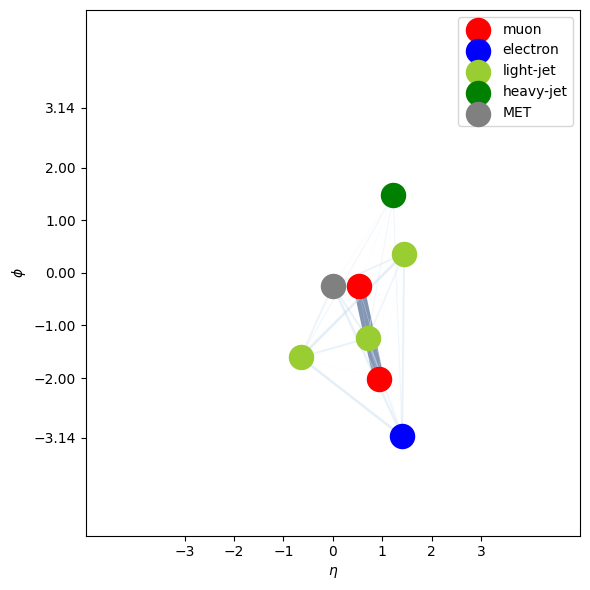

In [23]:
G = nx.Graph()
positions = {}
muons = []
electrons = []
jets = []
bjets = []
METv = []
for i, features in enumerate(data.x):
    thisParticle = ROOT.TLorentzVector()
    thisParticle.SetPxPyPzE(features[1], features[2], features[3], features[0])
    positions[i] = (thisParticle.Eta(), thisParticle.Phi())
for i, particleType in enumerate(data.particleTypes):
    if particleType == "muon": muons.append(i)
    if particleType == "electron": electrons.append(i)
    if particleType == "light-jet": jets.append(i)
    if particleType == "heavy-jet": bjets.append(i)
    if particleType == "METv": METv.append(i)
G.add_nodes_from(positions.keys())
G.add_edges_from(edge_mask_dict.keys())
edge_color = [edge_mask_dict[(u, v)] for u, v, in G.edges()]
widths = [x*10 for x in edge_color]

plt.figure(figsize=(6, 6))
nx.draw_networkx_nodes(G, positions, nodelist=muons, node_color="red", label="muon")
nx.draw_networkx_nodes(G, positions, nodelist=electrons, node_color="blue", label="electron")
nx.draw_networkx_nodes(G, positions, nodelist=jets, node_color="yellowgreen", label="light-jet")
nx.draw_networkx_nodes(G, positions, nodelist=bjets, node_color="green", label="heavy-jet")
nx.draw_networkx_nodes(G, positions, nodelist=METv, node_color="gray", label="MET")
nx.draw_networkx_edges(G, positions, edgelist=edge_mask_dict.keys(), edge_color=edge_color, alpha=0.5, width=widths, edge_cmap=plt.cm.Blues)
plt.legend(loc="upper right")
plt.xlabel(r"$\eta$")
plt.ylabel(r"$\phi$")
plt.xlim(-5, 5)
plt.ylim(-5, 5)
plt.xticks([-3., -2., -1., 0., 1., 2., 3])
plt.yticks([-3.14, -2., -1., 0., 1., 2., 3.14])
plt.tick_params(left=True, bottom=True, labelleft=True, labelbottom=True)
plt.tight_layout()
plt.show()